Student Performance Data Analysis

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_excel('/content/student-1.xlsx')

In [43]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


To create the new target column, G4, by summing the three period grades

In [45]:
df['G4'] = df['G1'] + df['G2'] + df['G3']

print(df[['G1', 'G2', 'G3', 'G4']].head())

   G1  G2  G3  G4
0   0  11  11  22
1   9  11  11  31
2  12  13  12  37
3  14  14  14  42
4  11  13  13  37


To find strong relationships with a variable in a dataset we can employ various statistical and visualization techniques, depending on the nature of variables (numerical or categorical).

**For Numerical Variables (Linear Relationships)**:
- Correlation Coefficients:
  1. Pearson Method:    
  Coefficient close to +1 or -1 indicates a strong positive or negative linear correlation, respectively. A value close to 0 suggests no linear correlation.
  2. Kendall's Tau:    
  Rank-based correlation measure, often used with smaller datasets or when ties are present in the ranks.

- Scatter Plots: Visualizing the relationship between two numerical variables can reveal patterns, linearity, and potential outliers.      
or     
Regression Plots can be used

**For Categorical Variables (Association)**:
- Chi-Squared Test of Independence: Used to determine if there's a significant association between two categorical variables.

- Grouped bar chart: A strong relationship exists if the pattern of bar heights for one variable is very different across the groups of the other variable. If the pattern of bar heights is similar for all groups, there is likely a weak relationship or no relationship.

- Stacked bar chart: A strong relationship is present if the proportions of the stacked segments vary notably from one bar to the next. If the segments in all bars are roughly the same size, the variables are likely independent.

- Heatmap: A strong relationship is visually clear when the heatmap shows significant variation in color intensity across the grid. Darker squares may indicate a higher frequency for a specific category combination, while lighter squares indicate a lower frequency. A heatmap with mostly uniform color suggests a weak or nonexistent relationship.     
or     
Box Plots, Violin Plots etc... can be used.



### Analyzing Effects of `studytime` and `G4`

Text(0, 0.5, 'Final Grade')

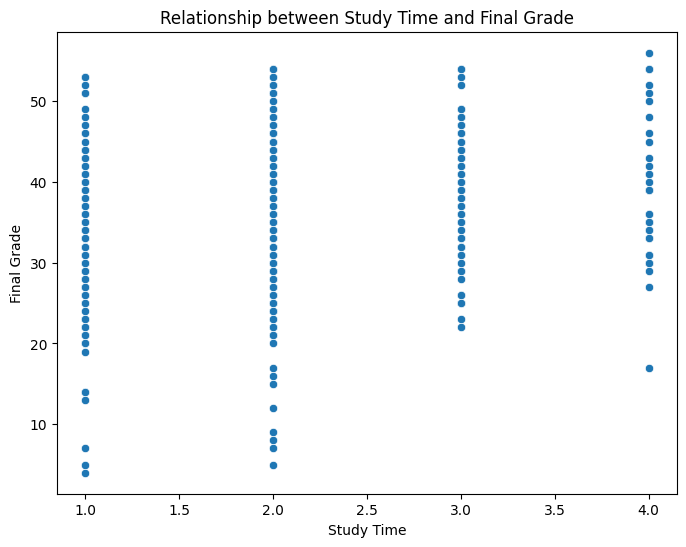

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='studytime', y='G4')
plt.title('Relationship between Study Time and Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')

the points are quite spread out, suggesting that there isn't a perfect linear relationship between study time and the final grade.

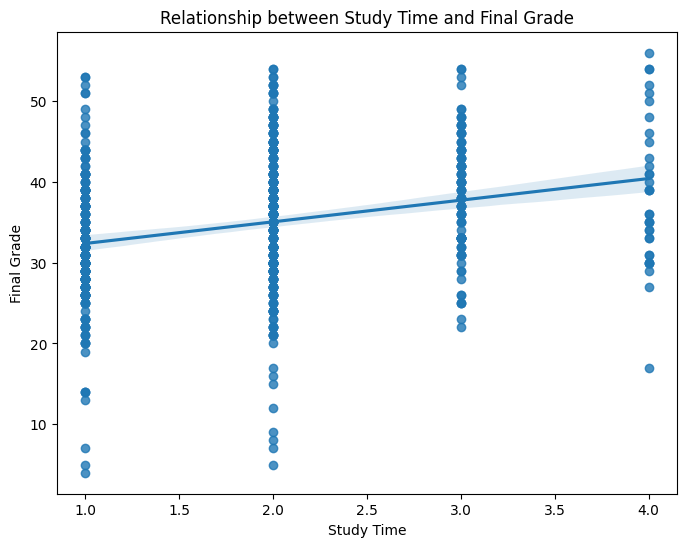

In [48]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='studytime', y='G4')
plt.title('Relationship between Study Time and Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.show()

as study time increases, the final grade tends to increase as well.

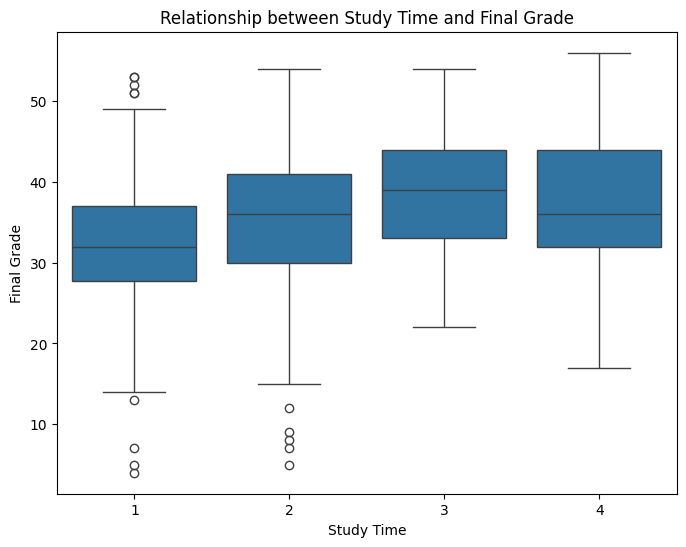

In [49]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='studytime', y='G4')
plt.title('Relationship between Study Time and Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.show()

The box plot illustrates a clear positive relationship between study time and final grades. Students who spent more time studying generally achieved higher and more consistent scores. The median grade increases steadily from Study Time 1 to Study Time 3, indicating that additional study hours contribute to better performance. However, beyond Study Time 3, the improvement plateaus, suggesting diminishing returns with excessive study time. Additionally, lower study times show greater variability and more low-grade outliers, while higher study times exhibit fewer poor performances, reflecting more stable academic outcomes among students who study more.

Text(0, 0.5, 'Mean Final Grade')

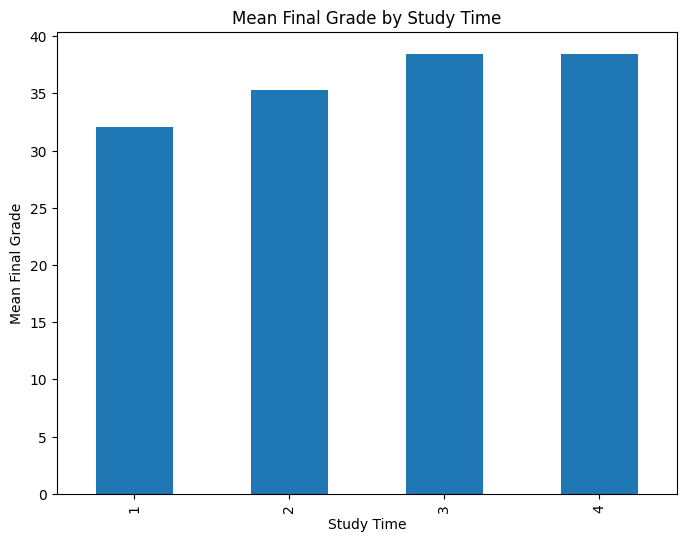

In [61]:
# Bar Plot of Mean for study time & G4
plt.figure(figsize=(8, 6))
df.groupby('studytime')['G4'].mean().plot(kind='bar')
plt.title('Mean Final Grade by Study Time')
plt.xlabel('Study Time')
plt.ylabel('Mean Final Grade')

The trend suggests that increased study time contributes to better academic performance, though the improvement plateaus slightly between study time categories 3 and 4. This indicates that while studying more generally leads to higher grades, beyond a certain point, additional study time yields diminishing returns.

### Analyzing relationsip of failures

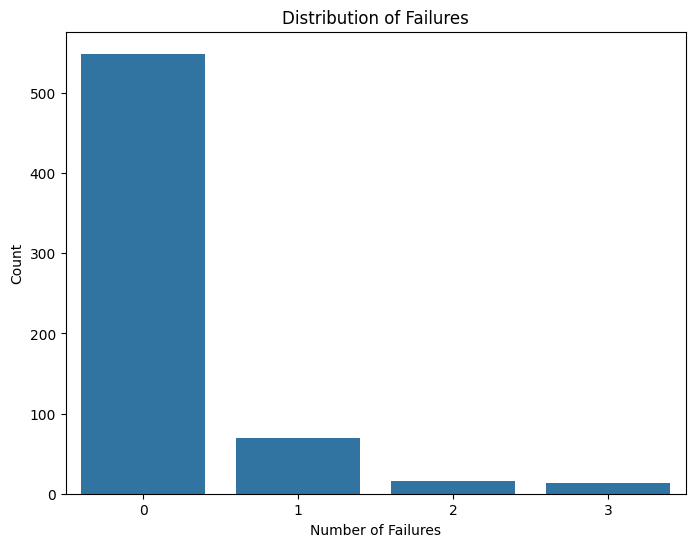

In [50]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='failures')
plt.title('Distribution of Failures')
plt.xlabel('Number of Failures')
plt.ylabel('Count')
plt.show()

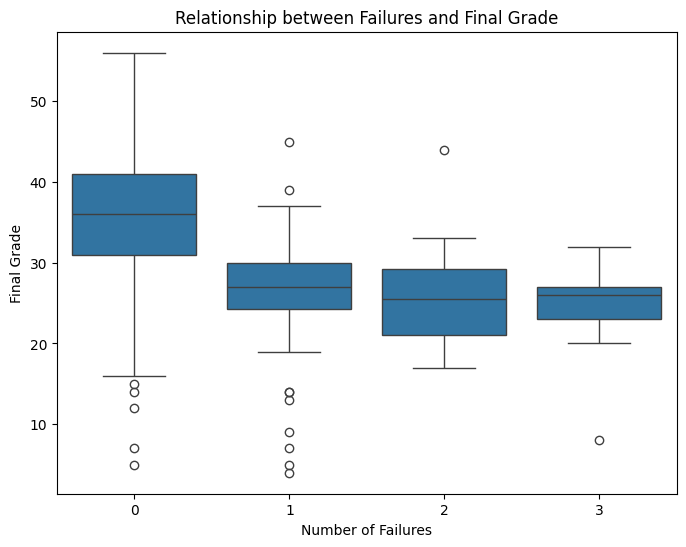

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='failures', y='G4')
plt.title('Relationship between Failures and Final Grade')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')
plt.show()

The box plot reveals a clear negative relationship between the number of past failures and final grades. Students with no prior failures tend to achieve the highest and most consistent final grades, with a higher median and a wider grade range toward the upper end. As the number of failures increases, both the median and overall grade range decline steadily. Students with two or more failures have notably lower median scores and reduced grade variability, indicating consistently poorer performance. This pattern suggests that repeated academic failures are associated with lower overall achievement and may reflect underlying learning challenges or motivational issues that affect final grades.

Text(0, 0.5, 'Final Grade')

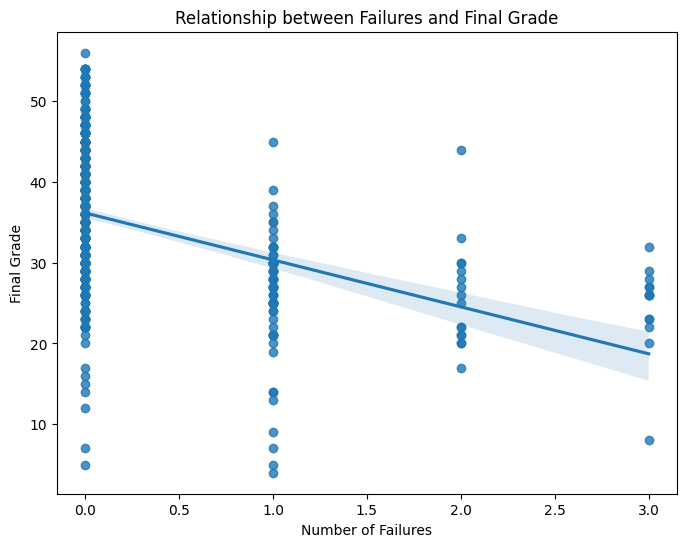

In [52]:
# reg plot of failures
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='failures', y='G4')
plt.title('Relationship between Failures and Final Grade')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')

The scatter plot with a regression line shows a negative linear relationship between the number of failures and final grades. As the number of failures increases, students’ final grades tend to decrease. The downward-sloping trend line clearly indicates that students with no prior failures achieve higher average grades, while those with one or more failures show progressively lower performance. The shaded region around the line represents the confidence interval, suggesting that the decline in grades is statistically consistent. Overall, this pattern highlights that academic failures are a strong indicator of reduced final performance, possibly reflecting learning difficulties, lack of motivation, or other academic challenges.

### Analyzing effect of internet access

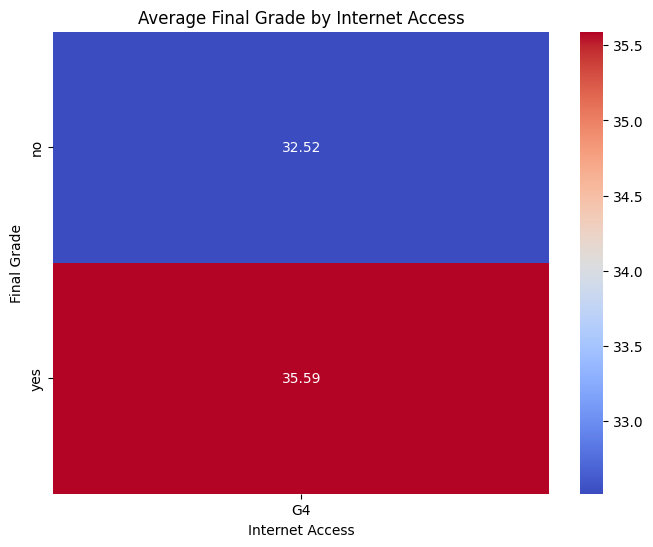

In [55]:
# Heatmap for internet access
plt.figure(figsize=(8, 6))
sns.heatmap(df.pivot_table(index='internet', values='G4', aggfunc='mean'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average Final Grade by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Final Grade')
plt.show()

The heatmap compares the average final grades of students based on whether they have internet access at home. Students with internet access (“yes”) have a higher average final grade of 35.59, while those without internet access (“no”) have a lower average grade of 32.52. This difference suggests a positive impact of internet access on academic performance, possibly because online resources and digital learning tools enhance students’ ability to study and complete assignments effectively. Although the gap is moderate, it indicates that access to educational technology may contribute to better academic outcomes.

### Analyzing relationship with Parents Jobs

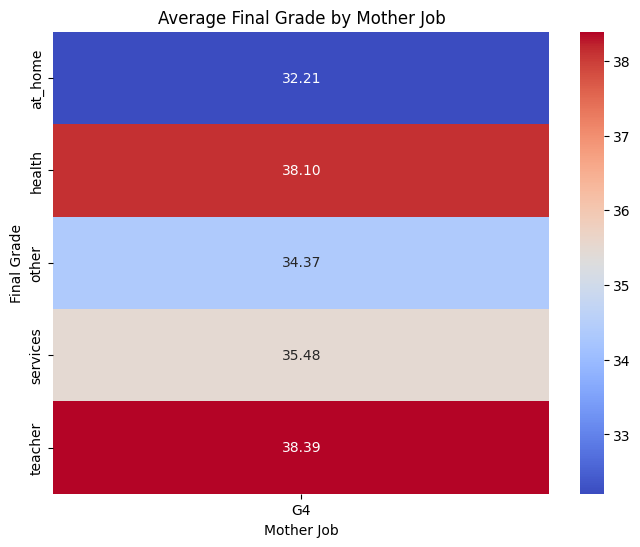

In [57]:
# heatmap for mothera job
plt.figure(figsize=(8, 6))
sns.heatmap(df.pivot_table(index='Mjob', values='G4', aggfunc='mean'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average Final Grade by Mother Job')
plt.xlabel('Mother Job')
plt.ylabel('Final Grade')
plt.show()

The heatmap shows noticeable variation in students’ average final grades based on their mother’s occupation.

Students whose mothers work as teachers (38.39) or in health professions (38.10) have the highest average grades, suggesting a positive influence from educational and health-related professions, possibly due to better academic support at home.

Those whose mothers work in services (35.48) or other fields (34.37) have moderate performance.

Students whose mothers are at home (32.21) tend to have the lowest average grades, which might indicate limited exposure to academic or professional environments that promote strong study habits.

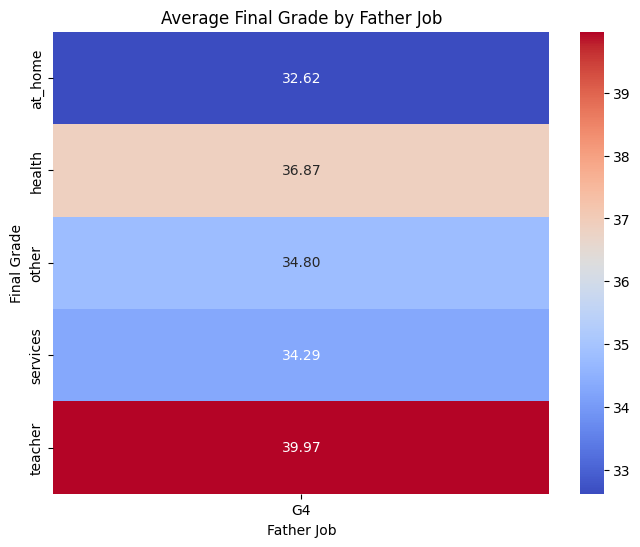

In [58]:
# Relationship with fathers job
plt.figure(figsize=(8, 6))
sns.heatmap(df.pivot_table(index='Fjob', values='G4', aggfunc='mean'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Average Final Grade by Father Job')
plt.xlabel('Father Job')
plt.ylabel('Final Grade')
plt.show()

The highest average grades are seen among students whose fathers are teachers (39.97), followed by those in health (36.87), highlighting again that parents in education or health fields may foster academic success.

Students with fathers in other (34.80) or services (34.29) roles perform moderately.

Those with fathers at home (32.62) have the lowest average, mirroring the mother’s job trend.

**Key Insights**

Parental education and professional background appear to positively influence student performance, especially in teaching and healthcare professions.

Both charts show a consistent pattern — students with professionally active parents (particularly teachers) tend to perform better than those with parents not engaged in professional work.

These findings may reflect higher academic expectations, better learning environments, and stronger educational support at home among families with educated or professionally active parents.

### Analyzing the travel time effect on G4

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

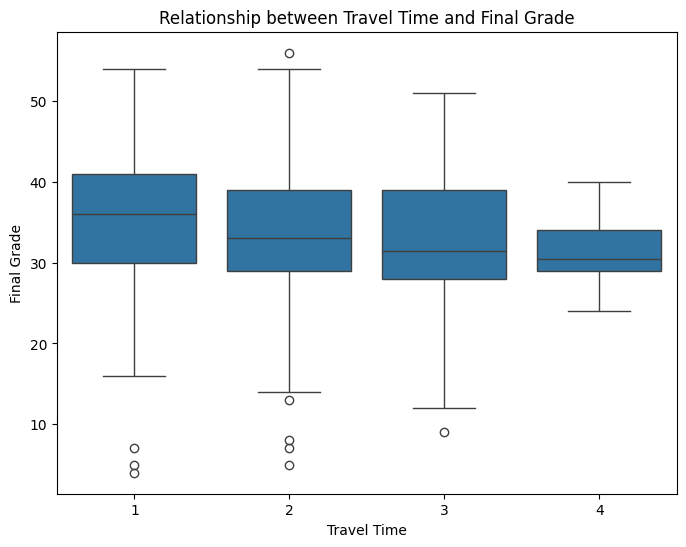

In [59]:
# Analyzing the travel time effect on G4
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='traveltime', y='G4')
plt.title('Relationship between Travel Time and Final Grade')
plt.xlabel('Travel Time')
plt.ylabel('Final Grade')
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

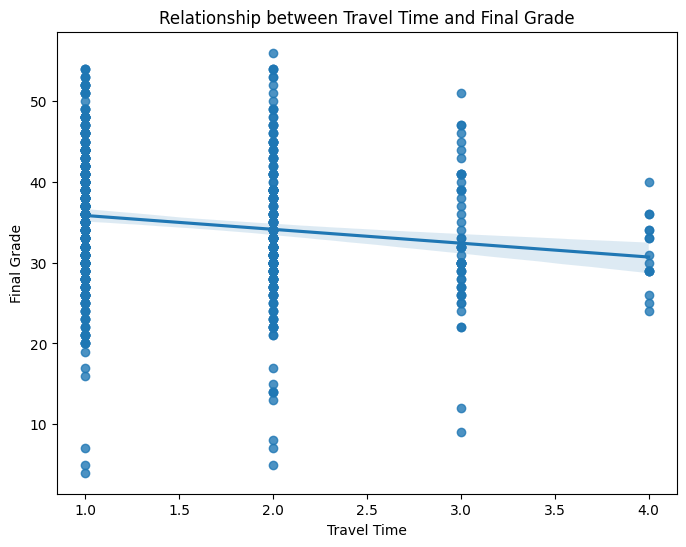

In [60]:
# Analyzing the travel time effect on G4 through regplot
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='traveltime', y='G4')
plt.title('Relationship between Travel Time and Final Grade')
plt.xlabel('Travel Time')
plt.ylabel('Final Grade')
plt

The scatter plot with a regression line indicates a slight negative relationship between students’ travel time to school and their final grades. As travel time increases, the average final grade tends to decrease marginally. Students with shorter travel times (closer proximity to school) generally achieve slightly higher grades compared to those who spend more time commuting. The downward slope of the regression line, though not steep, suggests that longer travel times may have a minor adverse impact on academic performance, possibly due to fatigue, reduced study time, or less engagement in school activities. However, the relatively broad scatter of points implies that travel time alone does not strongly determine student performance — other factors likely play a more significant role.

### Analyzing Effect of School Support

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

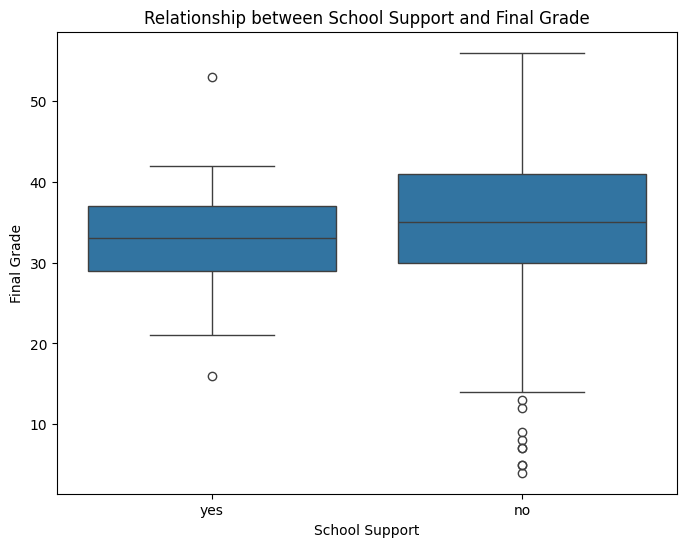

In [63]:
# Analyzing Effect of School Support on G4
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='schoolsup', y='G4')
plt.title('Relationship between School Support and Final Grade')
plt.xlabel('School Support')
plt.ylabel('Final Grade')
plt

Students without school support (“no”) have a slightly higher median grade than those with support (“yes”).

However, the range of grades is wider for the “no” group, showing both higher maximum grades and more low-end outliers.

Students with support show more consistency, with grades more tightly grouped around the median and fewer extreme low scores.

This suggests that while students without school support may include some high performers, school support helps maintain steadier academic performance and reduces the likelihood of very low grades.

### Analyzing the effect of Romantic Relationship on G4

Text(0.5, 0, 'Final Grade')

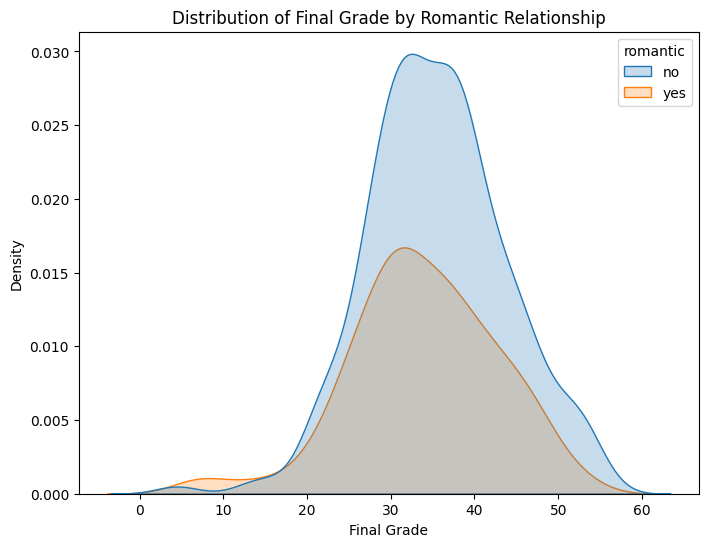

In [64]:
# KDE Plot for Romantic Relationship & G4
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='G4', hue='romantic', fill=True)
plt.title('Distribution of Final Grade by Romantic Relationship')
plt.xlabel('Final Grade')

The plot shows that students without a romantic relationship generally achieve slightly higher and more consistent final grades, with their scores clustering around the 30–35 range. In contrast, those in a romantic relationship display a wider spread of grades and a slightly lower average, suggesting that being in a relationship may be linked to greater variability and a modest decline in academic performance.

### Analyzing Effect of Mothers Education

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

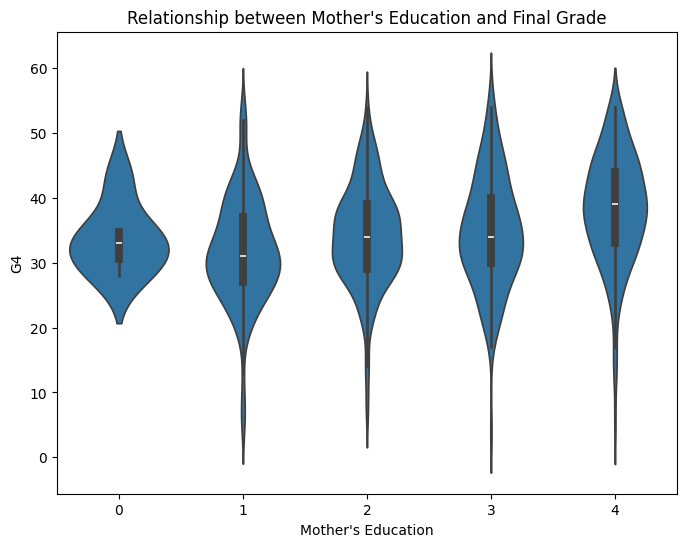

In [65]:
# Analyzing Effect of Mothers Education on G4 with violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Medu', y='G4')
plt.title('Relationship between Mother\'s Education and Final Grade')
plt.xlabel('Mother\'s Education')
plt

Overall, there is a positive trend—students whose mothers have higher education levels (coded 3 and 4) tend to achieve slightly higher median grades and show a wider range of higher scores. In contrast, students with mothers having lower education levels (0 or 1) generally have lower median grades and a narrower distribution. This suggests that parental education, particularly the mother’s, may influence academic performance, possibly due to greater academic support and encouragement at home.

### Analyzing Effect of Absences

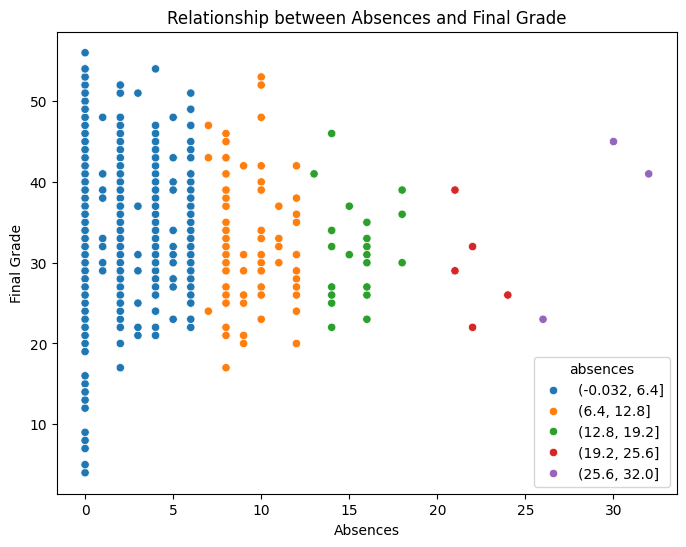

In [66]:
# Effect of Absences on G4 using scatter plot (binned)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='absences', y='G4', hue=pd.cut(df['absences'], bins=5))
plt.title('Relationship between Absences and Final Grade')
plt.xlabel('Absences')
plt.ylabel('Final Grade')
plt.show()

There is a clear negative correlation — as the number of absences increases, final grades tend to decrease. Students with few absences (0–6 days) generally achieve higher grades, while those with more frequent absences show a broader spread of lower scores. The pattern suggests that consistent attendance is linked to better academic performance, likely because students who attend regularly are more engaged and keep up with coursework.

## Insights
Here is a selection of six visuals that have strongest relationships with G4.

#### Visualization 1: Numerical-Numerical Relationship (Strongest Correlation)
- Variables: failures vs. G4
- Reasoning: The number of past class failures is often one of the strongest predictors of future performance. The inverse relationship should be very clear.
- Type: Scatter Plot

#### Visualization 2: Categorical-Numerical Relationship (Distribution Comparison)
- Variables: schoolsup (Extra educational support) vs. G4
- Reasoning: This binary variable is crucial for seeing if extra support translates to a performance difference. A Box Plot clearly shows the median, quartiles, and outliers.
- Type: Box Plot

### Visualization 3: Numerical-Numerical Relationship (Trend over Time/Effort)

- Variables: studytime (Weekly study time) vs. G4
- Reasoning: Shows the impact of effort. Since studytime is ordinal (1 to 4), a Bar Plot of the Mean is effective at showing the average G4 for each level of study time.
- Type: Bar Plot of Mean

### Visualization 4: Categorical-Numerical Relationship (Detailed Distribution)
- Variables: Medu (Mother's education) vs. G4
- Reasoning: Parental education is a strong socioeconomic factor. A Violin Plot shows the full shape of the G4 distribution (not just quartiles) for each education level.
- Type: Violin Plot

### Visualization 5: Numerical-Numerical Relationship (Outlier/Spread)
- Variables: absences vs. G4
- Reasoning: High absences likely correlate with low performance, but the relationship might be messy. A scatter plot helps identify high-leverage points. Use a log scale or binned scatter for better visualization of dense data points.
- Type: Scatter Plot (binned or log-scaled)

### Visualization 6: Categorical-Categorical/Numerical Relationship
- Variables: romantic (Romantic relationship) vs. G4
- Reasoning: A simple binary feature that often shows a minor but noticeable impact on focus and performance.
- Type: KDE Plot (to compare smoothed distributions)

# Summary
- **Failures vs. G4 (Scatter Plot)**: This shows a strong negative relationship, indicating that more past failures are strongly associated with lower final grades.
- **School Support vs. G4 (Box Plot)**: Students without school support tend to have slightly higher median grades but also more variability and low outliers. School support seems to contribute to more consistent performance and fewer very low grades.
- **Study Time vs. G4 (Bar Plot of Mean)**: There's a positive trend where more study time generally leads to higher average final grades, though the improvement seems to plateau after a certain point.
- **Mother's Education vs. G4 (Violin Plot)**: Higher levels of mother's education are associated with slightly higher median grades and a wider range of higher scores among students, suggesting a positive influence on academic performance.
- **Absences vs. G4 (Scatter Plot - binned or log-scaled)**: A clear negative correlation exists, meaning more absences are linked to lower final grades. Consistent attendance appears important for better academic outcomes.
- **Romantic Relationship vs. G4 (KDE Plot)**: Students without a romantic relationship tend to have slightly higher and more consistent final grades compared to those in a relationship, who show more grade variability and a slightly lower average.